<a href="https://colab.research.google.com/github/Qophy/PBML/blob/main/copy_1_of_Copy_4_of_Model_1_00.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ─────────────────────────────────────────────
#  IMPORTS
# ─────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [ ]:
# ─────────────────────────────────────────────
#  REPRODUCIBILITY SEEDS
# ─────────────────────────────────────────────
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
# ─────────────────────────────────────────────
#  CENTRAL CONFIG
# ─────────────────────────────────────────────
CONFIG = {
    # Data
    "data_path": "/content/drive/MyDrive/PINN_WQS_dataset/wq_dataset_node_cycles_1DO.csv",   # update path as needed
    "test_size": 0.15,
    "val_size": 0.15,     # fraction of the ORIGINAL dataset
    "random_state": SEED,
    # Architecture
    "d_model": 32,
    "num_heads": 4,
    "key_dim": 16,
    "dropout_rate": 0.2,
    "n_targets": 2,
    "branch_units": [64, 64, 32],
    "interaction_units": [64, 64, 32],
    # Training
    "batch_size": 32,
    "epochs": 200,
    "learning_rate": 1e-3,
    "patience": 20,           # EarlyStopping patience
    "checkpoint_path": "best_model.weights.h5",
    # Targets / feature names (for reporting)
    "target_names": ["Conductivity", "pH"],
    "time_features": ["hour_sin", "hour_cos", "DOW_sin", "DOW_cos", "Mon_sin", "Mon_cos"],
    "env_features": ["Temperature", "DissolvedOxygen"],
    # Add separate loss weights
    "LOSS_WEIGHTS" : {
      "conductivity": 1.0,   # equal importance by default
      "ph":           0.20,   # pH errors penalised twice as heavily
    },
}

In [ ]:
# ─────────────────────────────────────────────
# 3. LOAD DATA
# ─────────────────────────────────────────────
raw_data = pd.read_csv(CONFIG["data_path"])
print("Dataset shape:", raw_data.shape)
print(raw_data.info())

time_var = raw_data[CONFIG["time_features"]].values
env_vars = raw_data[CONFIG["env_features"]].values
targets  = raw_data[CONFIG["target_names"]].values

Dataset shape: (18432, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18432 entries, 0 to 18431
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temperature      18432 non-null  float64
 1   Conductivity     18432 non-null  float64
 2   pH               18432 non-null  float64
 3   DissolvedOxygen  18432 non-null  float64
 4   hour_sin         18432 non-null  float64
 5   hour_cos         18432 non-null  float64
 6   DOW_sin          18432 non-null  float64
 7   DOW_cos          18432 non-null  float64
 8   Mon_sin          18432 non-null  float64
 9   Mon_cos          18432 non-null  float64
dtypes: float64(10)
memory usage: 1.4 MB
None


In [ ]:
# ─────────────────────────────────────────────
# SPLIT FIRST, THEN SCALE  (Fixes #1 & #2)
#    Three-way split: train / val / test
# ─────────────────────────────────────────────

# hold out the test set
(
    t_trainval, t_test,
    env_trainval, env_test,
    y_trainval, y_test,
) = train_test_split(
    time_var, env_vars, targets,
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_state"],
)

# split remaining data into train / val
val_fraction_of_trainval = CONFIG["val_size"] / (1.0 - CONFIG["test_size"])
(
    t_train, t_val,
    env_train, env_val,
    y_train, y_val,
) = train_test_split(
    t_trainval, env_trainval, y_trainval,
    test_size=val_fraction_of_trainval,
    random_state=CONFIG["random_state"],
)

print(f"\nSplit sizes  →  train: {len(t_train)}  |  val: {len(t_val)}  |  test: {len(t_test)}")


Split sizes  →  train: 12902  |  val: 2765  |  test: 2765


In [ ]:
def fit_scaler(train_array: np.ndarray) -> StandardScaler:
    """Fit a StandardScaler on training data only."""
    scaler = StandardScaler()
    scaler.fit(train_array)
    return scaler


def apply_scaler(scaler: StandardScaler, array: np.ndarray) -> np.ndarray:
    """Transform an array using an already-fitted scaler."""
    return scaler.transform(array)

In [ ]:
# fit scalers on TRAIN only, then transform all splits
# Note: time features are cyclically encoded (sin/cos) → already in [-1, 1];
# we still scale them for consistency but it has minimal effect.
time_scaler = fit_scaler(t_train)
env_scaler  = fit_scaler(env_train)
tgt_scaler  = fit_scaler(y_train)

t_train_scaled   = apply_scaler(time_scaler, t_train)
t_val_scaled     = apply_scaler(time_scaler, t_val)
t_test_scaled    = apply_scaler(time_scaler, t_test)

env_train_scaled = apply_scaler(env_scaler, env_train)
env_val_scaled   = apply_scaler(env_scaler, env_val)
env_test_scaled  = apply_scaler(env_scaler, env_test)

y_train_scaled   = apply_scaler(tgt_scaler, y_train)
y_val_scaled     = apply_scaler(tgt_scaler, y_val)
y_test_scaled    = apply_scaler(tgt_scaler, y_test)

In [ ]:
# ── Dataset: labels must also be a dict ───────────────────────────
def make_dict_dataset(t, env, y, batch_size, shuffle=False):
    """Wrap labels as a dict matching the model's output keys."""
    labels = {
        "conductivity": y[:, 0:1],
        "ph":           y[:, 1:2],
    }
    ds = tf.data.Dataset.from_tensor_slices(((t, env), labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(t), seed=SEED)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


train_dataset = make_dict_dataset(t_train_scaled, env_train_scaled, y_train_scaled, CONFIG["batch_size"], shuffle=False)
val_dataset   = make_dict_dataset(t_val_scaled,   env_val_scaled,   y_val_scaled,   CONFIG["batch_size"])
test_dataset  = make_dict_dataset(t_test_scaled,  env_test_scaled,  y_test_scaled,  CONFIG["batch_size"])

In [ ]:
# ─────────────────────────────────────────────
# MODEL COMPONENTS
# ─────────────────────────────────────────────

class SelfAttentionBlock(tf.keras.layers.Layer):
    """
    Dual-stream self-attention block.

    Each input stream (time / env) is:
      1. Projected to d_model via a Dense embedding layer   ← Fix #7
      2. Passed through multi-head self-attention
      3. Layer-normalised with a residual connection
    The two streams are concatenated and fused.

    Fix #3: only ONE definition of this class.
    """

    def __init__(self, d_model: int, num_heads: int, key_dim: int,
                 dropout_rate: float, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model

        # ── per-stream embedding (Fix #7) ──────────────────────────────────
        self.embed_time = tf.keras.layers.Dense(d_model, activation="relu",
                                                name="embed_time")
        self.embed_env  = tf.keras.layers.Dense(d_model, activation="relu",
                                                name="embed_env")

        # ── per-stream MHA ─────────────────────────────────────────────────
        mha_kw = dict(num_heads=num_heads, key_dim=key_dim,
                      dropout=dropout_rate)
        self.mha_time = tf.keras.layers.MultiHeadAttention(name="mha_time",
                                                           **mha_kw)
        self.mha_env  = tf.keras.layers.MultiHeadAttention(name="mha_env",
                                                           **mha_kw)

        # ── layer norms ────────────────────────────────────────────────────
        self.ln_time = tf.keras.layers.LayerNormalization()
        self.ln_env  = tf.keras.layers.LayerNormalization()

        # ── output projection ──────────────────────────────────────────────
        self.out_time = tf.keras.layers.Dense(d_model, name="out_time")
        self.out_env  = tf.keras.layers.Dense(d_model, name="out_env")
        self.fusion   = tf.keras.layers.Dense(d_model, activation="relu",
                                              name="fusion")

        self.dropout  = tf.keras.layers.Dropout(dropout_rate)

    def call(self, inputs, training=False):
        t_raw, env_raw = inputs   # (batch, t_feats), (batch, env_feats)

        # Embed: (batch, feats) → (batch, feats, d_model)
        t   = tf.expand_dims(self.embed_time(tf.expand_dims(t_raw,   -1)), axis=1)
        env = tf.expand_dims(self.embed_env(tf.expand_dims(env_raw,  -1)), axis=1)

        # Treat the feature axis as the sequence length
        # expand_dims gives (batch, 1, feats); reshape to (batch, feats, d_model)
        t   = tf.reshape(self.embed_time(
                  tf.reshape(t_raw,   [-1, tf.shape(t_raw)[-1], 1])),
              [-1, tf.shape(t_raw)[-1], self.d_model])

        env = tf.reshape(self.embed_env(
                  tf.reshape(env_raw, [-1, tf.shape(env_raw)[-1], 1])),
              [-1, tf.shape(env_raw)[-1], self.d_model])

        # Self-attention with residual + layer norm
        h_t = self.mha_time(query=t, key=t, value=t, training=training)
        h_t = self.ln_time(t + self.dropout(h_t, training=training))
        h_t = tf.reduce_mean(self.out_time(h_t), axis=1)   # pool tokens

        h_e = self.mha_env(query=env, key=env, value=env, training=training)
        h_e = self.ln_env(env + self.dropout(h_e, training=training))
        h_e = tf.reduce_mean(self.out_env(h_e), axis=1)    # pool tokens

        h = tf.concat([h_t, h_e], axis=-1)
        h = self.fusion(h)
        return h

    def get_config(self):
        base = super().get_config()
        base.update(d_model=self.d_model)
        return base

In [ ]:
def build_nn_branch(units: list, dropout_rate: float) -> tf.keras.Sequential:
    """Dense branch with Dropout regularisation (Fix #8)."""
    layers = []
    for u in units:
        layers += [
            tf.keras.layers.Dense(u, activation="tanh"),
            tf.keras.layers.Dropout(dropout_rate),
        ]
    layers.append(tf.keras.layers.Dense(1))
    return tf.keras.Sequential(layers)


In [ ]:
def build_interaction_module(units: list, dropout_rate: float) -> tf.keras.Sequential:
    """Interaction module with Dropout regularisation (Fix #8)."""
    layers = []
    for u in units:
        layers += [
            tf.keras.layers.Dense(u, activation="tanh"),
            tf.keras.layers.Dropout(dropout_rate),
        ]
    return tf.keras.Sequential(layers)

In [ ]:
class ParallelAttentionInteractionModel(tf.keras.Model):
    """
    Parallel Attention + Interaction model for multi-target regression.

    Each target gets its own attention block + NN branch (Level-1).
    All Level-1 representations pass through a shared interaction module,
    whose output feeds each target's dedicated output head (Level-2).
    """

    def __init__(self, cfg: dict, **kwargs):
        super().__init__(**kwargs)
        n   = cfg["n_targets"]
        d   = cfg["d_model"]
        dr  = cfg["dropout_rate"]
        nh  = cfg["num_heads"]
        kd  = cfg["key_dim"]

        self.n_targets = n
        self.target_names = cfg["target_names"]   # ["Conductivity", "pH"]

        self.attention_blocks = [
            SelfAttentionBlock(d, nh, kd, dr, name=f"sa_block_{i}")
            for i in range(n)
        ]
        self.nn_branches = [
            build_nn_branch(cfg["branch_units"], dr)
            for _ in range(n)
        ]
        self.interaction   = build_interaction_module(cfg["interaction_units"], dr)
        self.output_heads  = [tf.keras.layers.Dense(1, name=name.lower())
                               for name in cfg['target_names']]

    def call(self, inputs, training=False):
        time_var, env_vars = inputs
        x = (time_var, env_vars)

        phi_list = []
        for sa, nn in zip(self.attention_blocks, self.nn_branches):
            h   = sa(x, training=training)
            phi = nn(h,  training=training)
            phi_list.append(phi)

        phi_L1     = tf.concat(phi_list, axis=-1)
        h_interact = self.interaction(phi_L1, training=training)

        # Return DICT so Keras matches outputs to loss keys by name
        return {
            name.lower(): head(h_interact)
            for name, head in zip(self.target_names, self.output_heads)
        }



In [ ]:
# ─────────────────────────────────────────────
#  BUILD & COMPILE
# ─────────────────────────────────────────────
model = ParallelAttentionInteractionModel(CONFIG)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG["learning_rate"]),
    # One loss function per named output key
    loss= {
        "conductivity": "mse",
        "ph"          : "mse",
    },
    loss_weights=CONFIG['LOSS_WEIGHTS'],
    metrics= {
        "conductivity": ["mae"],
        "ph"          : ["mae"],
    },
)

In [ ]:
# ─────────────────────────────────────────────
#  CALLBACKS
# ─────────────────────────────────────────────
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=CONFIG["patience"],
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=CONFIG["checkpoint_path"],
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=CONFIG["patience"] // 2,
        min_lr=1e-6,
        verbose=1,
    ),
]

In [ ]:
# ─────────────────────────────────────────────
#  TRAIN  — validation set separate from test
# ─────────────────────────────────────────────
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=CONFIG["epochs"],
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/200
403/404 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - conductivity_loss: 0.7893 - conductivity_mae: 0.6386 - loss: 0.9956 - ph_loss: 1.0316 - ph_mae: 0.8094
Epoch 1: val_loss improved from None to 0.68382, saving model to best_model.weights.h5

Epoch 1: finished saving model to best_model.weights.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 33s 23ms/step - conductivity_loss: 0.6994 - conductivity_mae: 0.5965 - loss: 0.8997 - ph_loss: 0.9981 - ph_mae: 0.7970 - val_conductivity_loss: 0.5047 - val_conductivity_mae: 0.4891 - val_loss: 0.6838 - val_ph_loss: 0.8968 - val_ph_mae: 0.7631 - learning_rate: 0.0010
Epoch 2/200
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - conductivity_loss: 0.5863 - conductivity_mae: 0.5305 - loss: 0.7530 - ph_loss: 0.8332 - ph_mae: 0.7342
Epoch 2: val_loss improved from 0.68382 to 0.51753, saving model to best_model.weights.h5

Epoch 2: finished saving model to best_model.weights.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - conductivity_loss: 0.5576 - conductivity_mae: 0.5

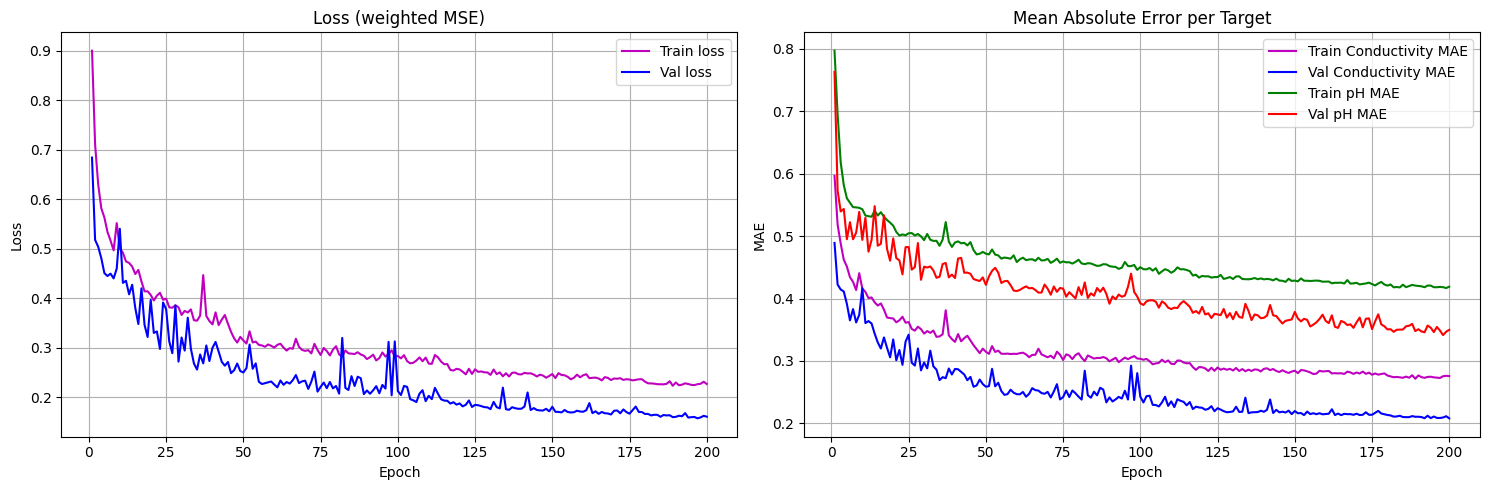

In [ ]:
# ─────────────────────────────────────────────
#  PLOT TRAINING HISTORY
# ─────────────────────────────────────────────
def plot_training_history(history):
    loss     = history.history["loss"]
    val_loss = history.history["val_loss"]

    # Extract individual MAE metrics
    conductivity_mae = history.history["conductivity_mae"]
    val_conductivity_mae = history.history["val_conductivity_mae"]
    ph_mae = history.history["ph_mae"]
    val_ph_mae = history.history["val_ph_mae"]

    epochs   = range(1, len(loss) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(epochs, loss,     "m",  label="Train loss")
    axes[0].plot(epochs, val_loss, "b",  label="Val loss")
    axes[0].set_title("Loss (weighted MSE)") # Changed title to reflect weighted loss
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss") # Changed ylabel from MSE to Loss
    axes[0].legend(); axes[0].grid(True)

    # Plot individual MAE metrics
    axes[1].plot(epochs, conductivity_mae,     "m",  label="Train Conductivity MAE")
    axes[1].plot(epochs, val_conductivity_mae, "b",  label="Val Conductivity MAE")
    axes[1].plot(epochs, ph_mae,               "g",  label="Train pH MAE") # Using a different color
    axes[1].plot(epochs, val_ph_mae,           "r",  label="Val pH MAE")   # Using a different color
    axes[1].set_title("Mean Absolute Error per Target") # More descriptive title
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("MAE")
    axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    plt.savefig("training_history.png", dpi=150)
    plt.show()


plot_training_history(history)


In [ ]:
# ─────────────────────────────────────────────
#  EVALUATE ON TEST SET — per-target metrics
# ─────────────────────────────────────────────
predictions_scaled = model.predict((t_test_scaled, env_test_scaled))

# Correctly inverse transform the stacked predictions
predictions = tgt_scaler.inverse_transform(
    np.hstack([predictions_scaled["conductivity"], predictions_scaled["ph"]])
)
Y_test_actual = tgt_scaler.inverse_transform(y_test_scaled)

per_target_metrics = {} # Initialize dictionary to store metrics

for i, name in enumerate(CONFIG["target_names"]):
  col = Y_test_actual[:, i]
  pred = predictions[:, i] # Use the correctly stacked predictions
  rmse = np.sqrt(mean_squared_error(col, pred))
  mse = mean_squared_error(col, pred)
  mae = mean_absolute_error(col, pred)
  r2 = r2_score(col, pred)

  per_target_metrics[name] = {
      "RMSE": rmse,
      "MSE": mse,
      "MAE": mae,
      "R2": r2
  }

  print(f"{name} RMSE: {rmse:.4f}"
        f"  |  MSE: {mse:.4f}"
        f"  |  MAE: {mae:.4f}"
        f"  |  R2: {r2:.4f}")

87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
Conductivity RMSE: 28.3057  |  MSE: 801.2110  |  MAE: 18.9018  |  R2: 0.9007
pH RMSE: 1.0064  |  MSE: 1.0128  |  MAE: 0.6710  |  R2: 0.7194


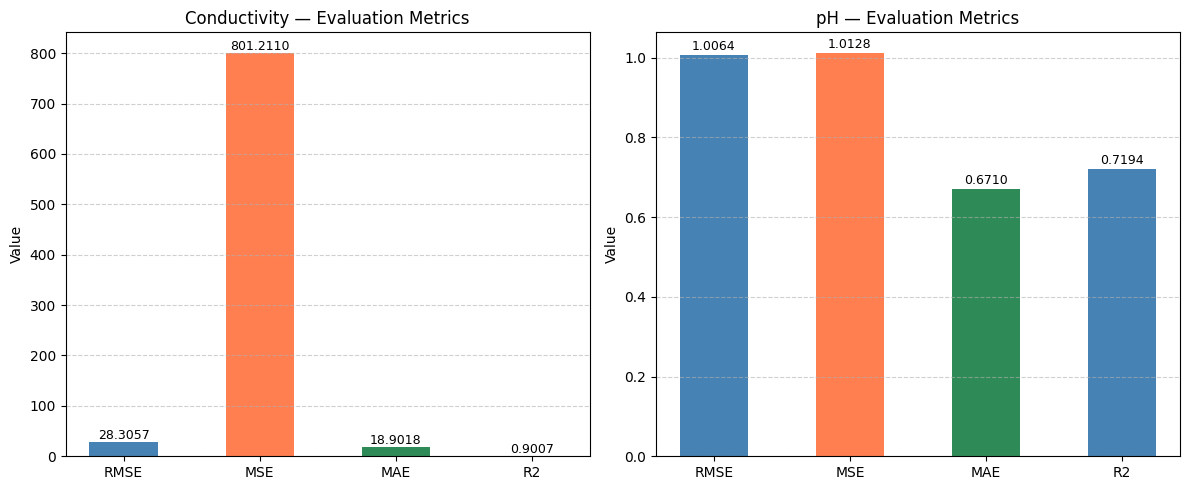

In [ ]:
# ─── Per-target metric bar charts (Fix #6 — no mixed-unit axes) ────────────
target_names = CONFIG["target_names"]
fig, axes = plt.subplots(1, len(target_names),
                         figsize=(6 * len(target_names), 5))

# Handle the case of a single target; subplots returns a single ax not an array
if len(target_names) == 1:
    axes = [axes]

for ax, name in zip(axes, target_names):
    m      = per_target_metrics[name]
    labels = list(m.keys())
    values = list(m.values())
    colors = ["steelblue", "coral", "seagreen"]

    bars = ax.bar(labels, values, color=colors, width=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{val:.4f}", ha="center", va="bottom", fontsize=9)

    ax.set_title(f"{name} — Evaluation Metrics")
    ax.set_ylabel("Value")
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("evaluation_metrics.png", dpi=150)
plt.show()

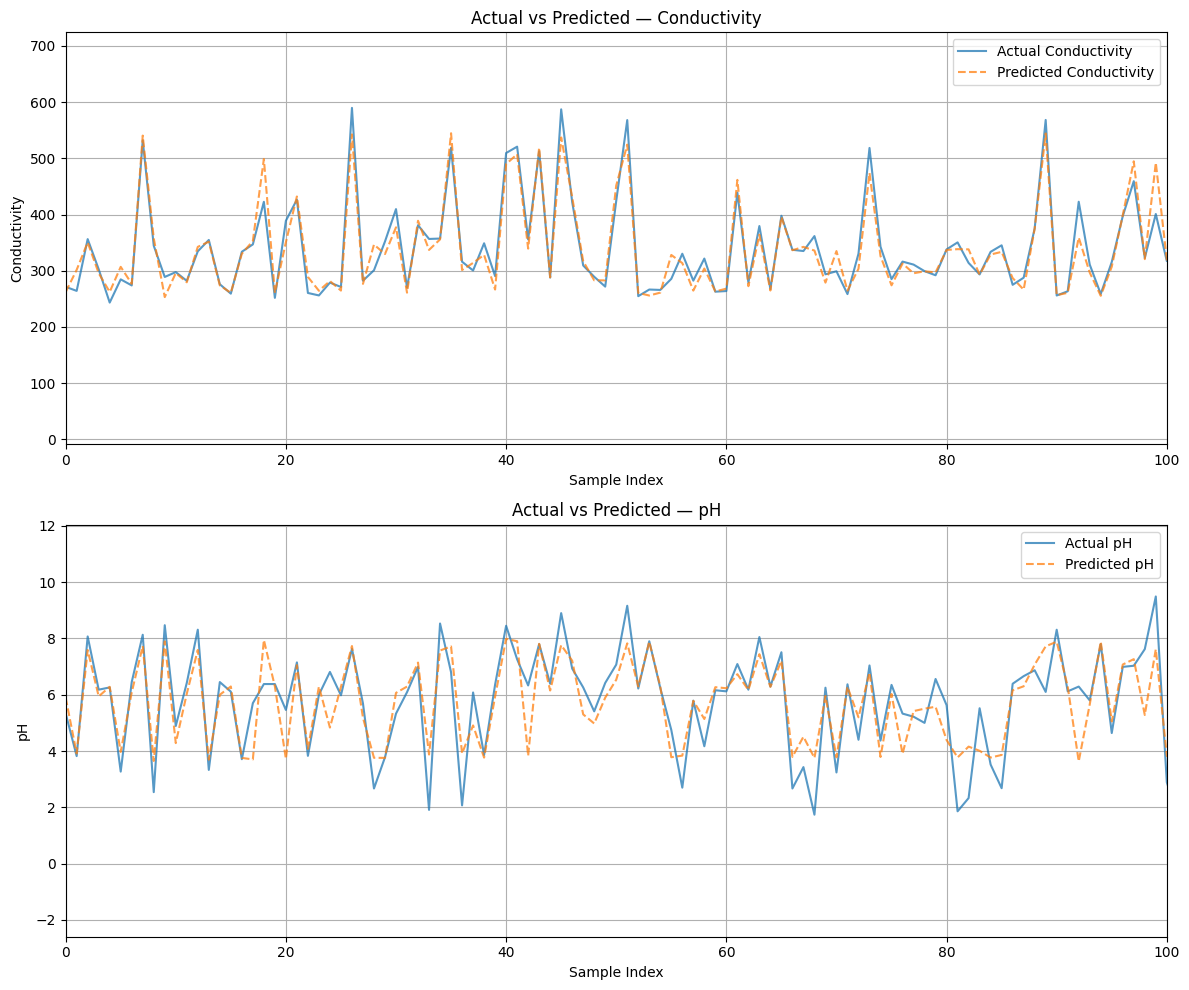

In [ ]:
# ─────────────────────────────────────────────
#  ACTUAL vs PREDICTED PLOTS
# ─────────────────────────────────────────────
fig, axes = plt.subplots(len(target_names), 1,
                         figsize=(12, 5 * len(target_names)))

for ax, name, i in zip(axes, target_names, range(len(target_names))):
    ax.plot(Y_test_actual[:, i], label=f"Actual {name}",    alpha=0.75)
    ax.plot(predictions[:, i],  label=f"Predicted {name}",  alpha=0.75,
            linestyle="--")
    ax.set_title(f"Actual vs Predicted — {name}")
    ax.set_xlabel("Sample Index")
    ax.set_ylabel(name)
    ax.legend()
    ax.grid(True)
    ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150)
plt.show()